# Chapter 6: Numerical Linear Algebra

This notebook covers practical numerical linear algebra with Python:

1. **Basic Linear Algebra** — matrices, eigenvalues, SVD
2. **Numerical Criteria** — sensitivity, stability, condition numbers
3. **Solving Linear Equations** — LU and Cholesky decomposition
4. **Eigenvalue Algorithms** — Power Method and QR Method
5. **Sparse Matrices** — efficient storage and solvers
6. **Randomised Algorithms** — sketching and randomised SVD
7. **GPU Acceleration** — CuPy overview

**Guiding principle**: prefer built-in NumPy/SciPy functions over manual implementations — hundreds of experts have spent years optimising them.

In [1]:
import numpy as np
import scipy.linalg as la
from scipy import sparse
from scipy.sparse import linalg as spla
import matplotlib.pyplot as plt
import time

np.random.seed(42)   # reproducibility

---
## 1. Basics of Linear Algebra

### 1.1 Matrix Notation and Operations

A matrix $A \in \mathbb{R}^{m \times n}$ has $m$ rows and $n$ columns. Key operations:
- **Transpose**: $(A^T)_{ij} = A_{ji}$
- **Matrix multiply**: $(AB)_{ij} = \sum_k A_{ik} B_{kj}$, requires inner dimensions to match
- **Inverse**: $A^{-1}A = AA^{-1} = I$ (only square, full-rank matrices)
- **Trace**: $\text{tr}(A) = \sum_i A_{ii}$

In [ ]:
A = np.array([[1., 2.], [3., 4.]])
B = np.array([[5., 6.], [7., 8.]])

print("A =\n", A)
print("\nIdentity I =\n", np.eye(2))
print("\nA + B =\n", A + B)
print("\nA @ B (matrix multiply) =\n", A @ B)
print("\nA * B (entry-wise) =\n", A * B)   # NOT matrix multiply!
print("\nA.T (transpose) =\n", A.T)
print("\nnp.linalg.inv(A) =\n", np.linalg.inv(A))
print("\ntr(A) =", np.trace(A))

A =
 [[1. 2.]
 [3. 4.]]

Identity I =
 [[1. 0.]
 [0. 1.]]

A + B =
 [[ 6.  8.]
 [10. 12.]]

A @ B (matrix multiply) =
 [[19. 22.]
 [43. 50.]]

A * B (entry-wise) =
 [[ 5. 12.]
 [21. 32.]]

A.T (transpose) =
 [[1. 3.]
 [2. 4.]]

np.linalg.inv(A) =
 [[-2.   1. ]
 [ 1.5 -0.5]]

tr(A) = 5.0


> ⚠️ **Use `@` for matrix multiplication, not `*`** — `*` does element-wise multiplication.

### 1.2 Eigenvalues and Eigenvectors

For a matrix $A$, $\lambda$ is an **eigenvalue** and $v$ an **eigenvector** if $Av = \lambda v$.

For a *symmetric* matrix $A = U\Lambda U^T$ where:
- $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_d)$ — real eigenvalues in decreasing order
- $U = [u_1, \ldots, u_d]$ — orthonormal eigenvectors ($U^TU = I$)

**Variational form**: $\lambda_{\max}(A) = \max_{\|x\|\le 1} x^T A x$

In [3]:
# Create a symmetric matrix
n = 4
M = np.random.randn(n, n)
A_sym = M @ M.T    # symmetric positive semi-definite: A = M M^T

# eigh: specialised for symmetric matrices (returns real eigenvalues, sorted ascending)
eigenvalues, eigenvectors = np.linalg.eigh(A_sym)
print("Eigenvalues (ascending) :", eigenvalues)
print("Eigenvectors (columns)  :\n", eigenvectors)

# Verify: A v = lambda v
v1 = eigenvectors[:, 0]   # first eigenvector
lam1 = eigenvalues[0]
print("\nA v₁            :", A_sym @ v1)
print("λ₁ v₁            :", lam1 * v1)
print("Match?           :", np.allclose(A_sym @ v1, lam1 * v1))

# Verify reconstruction: A = U Λ U^T
Lambda = np.diag(eigenvalues)
U = eigenvectors
A_reconstructed = U @ Lambda @ U.T
print("\nReconstruction error:", np.max(np.abs(A_sym - A_reconstructed)))

Eigenvalues (ascending) : [0.11672408 0.84637788 3.70764037 9.48387072]
Eigenvectors (columns)  :
 [[ 0.30191507  0.64211164  0.59773398 -0.37316755]
 [ 0.28929081 -0.74544218  0.3500296  -0.48796113]
 [ 0.8867168   0.06190224 -0.44410852  0.11255683]
 [ 0.19720909 -0.1678592   0.56829657  0.78100632]]

A v₁            : [0.03524076 0.0337672  0.1035012  0.02301905]
λ₁ v₁            : [0.03524076 0.0337672  0.1035012  0.02301905]
Match?           : True

Reconstruction error: 5.329070518200751e-15


### 1.3 Singular Value Decomposition (SVD)

For any matrix $A \in \mathbb{R}^{m \times n}$ (even rectangular!):

$$A = U D V^T = \sum_{i=1}^r \sigma_i u_i v_i^T$$

where $\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r > 0$ are the **singular values**.

- Singular values = square roots of eigenvalues of $A^TA$
- The operator (spectral) norm: $\|A\|_2 = \sigma_1$
- Best rank-k approximation of A: keep only top k terms $\sum_{i=1}^k \sigma_i u_i v_i^T$

In [4]:
A = np.random.randn(5, 3)

# Full SVD
U, S, VT = np.linalg.svd(A, full_matrices=False)
print("A shape       :", A.shape)
print("U shape       :", U.shape)   # (5, 3) — left singular vectors
print("S (singular values):", S)    # (3,)
print("VT shape      :", VT.shape)  # (3, 3) — right singular vectors^T

# Verify: A = U diag(S) VT
A_reconstructed = U @ np.diag(S) @ VT
print("\nReconstruction error:", np.max(np.abs(A - A_reconstructed)))

# Rank-1 approximation
A_rank1 = S[0] * np.outer(U[:, 0], VT[0, :])
print("Rank-1 approx error:", np.linalg.norm(A - A_rank1, 'fro') / np.linalg.norm(A, 'fro'))

A shape       : (5, 3)
U shape       : (5, 3)
S (singular values): [2.72004085 1.72473102 0.62163628]
VT shape      : (3, 3)

Reconstruction error: 8.881784197001252e-16
Rank-1 approx error: 0.5589094645646734


---
## 2. Criteria for Numerical Algorithms

A good numerical algorithm must be fast **and** accurate. Two key concepts:

- **Sensitivity** (condition number): how much does the *answer* change when the *input* is perturbed?  → a property of the **problem**
- **Stability**: how much do rounding errors in the *computation* affect the result? → a property of the **algorithm**

### 2.1 Stability: Newton vs Method X

Both methods find $\sqrt{2}$ (a fixed point). The same initial error $x_0 = 1.4$ vs $1.42$.

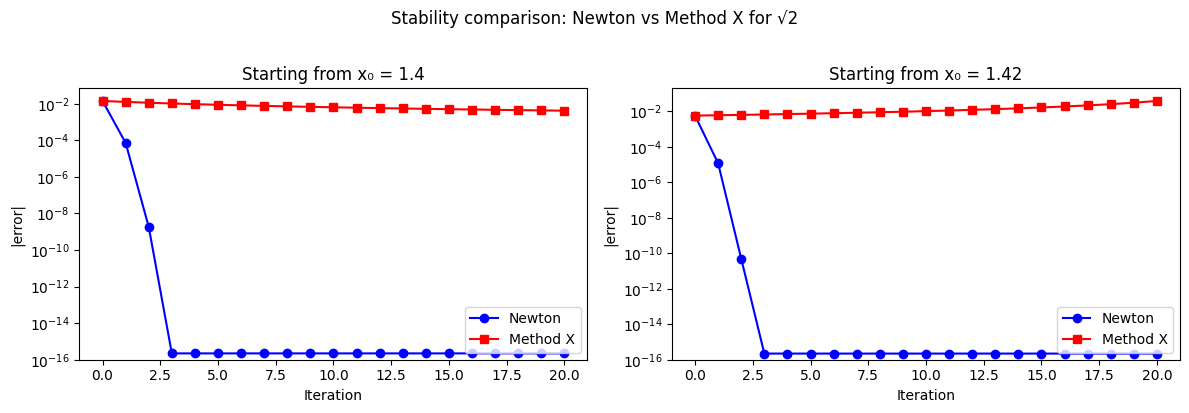

In [5]:
true_sqrt2 = 2**0.5

def newton_sqrt2(x0, n_iter=20):
    """x_{k+1} = (x_k + 2/x_k) / 2  — Newton-Raphson for sqrt(2)"""
    x = x0
    trajectory = [x]
    for _ in range(n_iter):
        x = (x + 2 / x) / 2
        trajectory.append(x)
    return trajectory

def method_x_sqrt2(x0, n_iter=20):
    """x_{k+1} = (x_k^2 - 2)^2 + x_k  — unstable fixed-point iteration"""
    x = x0
    trajectory = [x]
    for _ in range(n_iter):
        x = (x**2 - 2)**2 + x
        if abs(x) > 1e10:   # diverging
            break
        trajectory.append(x)
    return trajectory

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, x0 in zip(axes, [1.4, 1.42]):
    n_traj  = newton_sqrt2(x0)
    mx_traj = method_x_sqrt2(x0)
    ax.semilogy(range(len(n_traj)),  [abs(v - true_sqrt2) for v in n_traj],  'b-o', label='Newton')
    ax.semilogy(range(len(mx_traj)), [abs(v - true_sqrt2) for v in mx_traj], 'r-s', label='Method X')
    ax.set_xlabel('Iteration'); ax.set_ylabel('|error|')
    ax.set_title(f'Starting from x₀ = {x0}')
    ax.legend(); ax.set_ylim(1e-16, None)

plt.suptitle('Stability comparison: Newton vs Method X for √2', y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Catastrophic Cancellation

Subtracting two nearly equal numbers loses significant digits. Reformulate to avoid it.

$$f(x) = x(\sqrt{x+1} - \sqrt{x}) \quad \text{vs} \quad g(x) = \frac{x}{\sqrt{x+1}+\sqrt{x}}$$

Mathematically identical, but `f` suffers cancellation for large x.

In [6]:
import numpy as np

def f(x):
    return x * (np.sqrt(x + 1) - np.sqrt(x))

def g(x):
    return x / (np.sqrt(x + 1) + np.sqrt(x))  # rationalised form

# True value with high-precision reference
from decimal import Decimal, getcontext
getcontext().prec = 50

xs = [1, 10, 100, 500, 1e6, 1e12]
print(f"{'x':>12}  {'f(x)':>18}  {'g(x)':>18}")
print("-" * 52)
for x in xs:
    print(f"{x:12.0f}  {f(x):18.8f}  {g(x):18.8f}")

print("\n→ f(x) loses precision for large x; g(x) stays accurate.")

           x                f(x)                g(x)
----------------------------------------------------
           1          0.41421356          0.41421356
          10          1.54347130          1.54347130
         100          4.98756211          4.98756211
         500         11.17475530         11.17475530
     1000000        499.99987505        499.99987500
1000000000000     500003.80724669     499999.99999987

→ f(x) loses precision for large x; g(x) stays accurate.


---
## 3. Solving Linear Equations

We want to solve $Ax = b$ for $x \in \mathbb{R}^n$ given $A \in \mathbb{R}^{n \times n}$ and $b \in \mathbb{R}^n$.

**Time complexity**: O(n³) in general.  
**Condition number**: $\kappa(A) = \|A\| \cdot \|A^{-1}\| = \sigma_{\max}/\sigma_{\min}$ — a large condition number means the problem is ill-conditioned.

### 3.1 Condition Number Example

In [7]:
# Well-conditioned matrix
A_well = np.array([[2., 1.], [1., 2.]])
kappa_well = np.linalg.cond(A_well)
print(f"Well-conditioned κ(A) = {kappa_well:.2f}")

# Ill-conditioned matrix (nearly singular rows)
A_ill  = np.array([[1., 1.], [1., 1.001]])
kappa_ill  = np.linalg.cond(A_ill)
print(f"Ill-conditioned  κ(A) = {kappa_ill:.2f}")

# Effect: small perturbation in b → large change in x
b = np.array([2., 2.001])
x_well = np.linalg.solve(A_well, b)
x_ill  = np.linalg.solve(A_ill,  b)

b_pert = b + np.array([0, 0.001])   # tiny perturbation
x_well_p = np.linalg.solve(A_well, b_pert)
x_ill_p  = np.linalg.solve(A_ill,  b_pert)

print("\nChange in x for well-conditioned:", np.linalg.norm(x_well - x_well_p))
print("Change in x for ill-conditioned :", np.linalg.norm(x_ill  - x_ill_p))

Well-conditioned κ(A) = 3.00
Ill-conditioned  κ(A) = 4002.00

Change in x for well-conditioned: 0.0007453559924998479
Change in x for ill-conditioned : 1.4142135623730951


### 3.2 LU vs Cholesky Decomposition

For a symmetric positive definite (SPD) matrix:
- **LU decomposition** ($PA = LU$): general, ~$2n^3/3$ operations
- **Cholesky decomposition** ($A = LL^T$): only for SPD, ~$n^3/3$ operations — twice as fast!

Use `assume_a='pos'` in `scipy.linalg.solve` to tell SciPy to use Cholesky.

In [8]:
n = 1000
X = np.random.randn(n, n)
A_spd = X @ X.T + n * np.eye(n)   # SPD: X X^T + nI
b = np.random.randn(n)

results = {}
for label, kwargs in [
    ("General (LU)",        dict()),
    ("SPD (Cholesky)",      dict(assume_a='pos')),
    ("Symmetric",           dict(assume_a='sym')),
]:
    t0 = time.perf_counter()
    x = la.solve(A_spd, b, **kwargs)
    elapsed = time.perf_counter() - t0
    results[label] = (elapsed, x)
    print(f"{label:20s}: {elapsed:.4f}s")

# All should give the same answer
x_ref = results["General (LU)"][1]
for label, (_, x) in results.items():
    print(f"  {label:20s} vs General: max diff = {np.max(np.abs(x - x_ref)):.2e}")

General (LU)        : 0.0112s
SPD (Cholesky)      : 0.0094s
Symmetric           : 0.0198s
  General (LU)         vs General: max diff = 0.00e+00
  SPD (Cholesky)       vs General: max diff = 7.16e-18
  Symmetric            vs General: max diff = 9.54e-18


### 3.3 Tips for Solving Linear Equations

In [9]:
# TIP 1: NEVER use inv(A) @ b — use solve(A, b) instead
n = 200
A = np.random.randn(n, n) + n * np.eye(n)
b = np.random.randn(n)

x_inv   = np.linalg.inv(A) @ b          # DON'T do this
x_solve = np.linalg.solve(A, b)          # DO this instead
print("Error of inv vs solve:", np.linalg.norm(x_inv - x_solve))

# TIP 2: When solving Ax=b for MANY b vectors, save the LU decomposition
from scipy.linalg import lu, solve_triangular

P, L, U = lu(A)   # one-time O(n^3) decomposition

def solve_with_lu(b_vec):
    """O(n^2) per right-hand side using saved LU."""
    y = solve_triangular(L, P @ b_vec, lower=True)
    return solve_triangular(U, y)

# Compare: re-decompose vs reuse LU
B = np.random.randn(n, 50)  # 50 different right-hand sides

t0 = time.perf_counter()
for i in range(50): np.linalg.solve(A, B[:, i])
t_repeated = time.perf_counter() - t0

t0 = time.perf_counter()
P, L, U = lu(A)  # decompose once
for i in range(50): solve_with_lu(B[:, i])
t_lu = time.perf_counter() - t0

print(f"\n50 solves — re-decompose: {t_repeated:.4f}s  reuse LU: {t_lu:.4f}s  ({t_repeated/t_lu:.1f}× speedup)")

Error of inv vs solve: 5.1889564799744844e-17

50 solves — re-decompose: 0.0075s  reuse LU: 0.0032s  (2.4× speedup)


### 3.4 Stability of LU Decomposition

Naive LU without pivoting is numerically unstable. `scipy.linalg.lu` uses **partial pivoting** ($PA = LU$) to avoid this.

In [10]:
# Ill-conditioned matrix — tiny pivot without reordering
eps = 1e-15
A_bad = np.array([[eps, 1.], [1., 1.]])
b_bad = np.array([1., 2.])

# True solution (from Cramer's rule analytically): x ≈ [1, 1]
x_true = np.array([(2 - 1) / (1 - eps), (2*eps - 1) / (eps - 1)])

P, L, U = lu(A_bad)
y = solve_triangular(L, P @ b_bad, lower=True)
x_lu = solve_triangular(U, y)
print("With pivoting  x =", x_lu)
print("True solution  x ≈", x_true)
print("Error:", np.linalg.norm(x_lu - x_true))

With pivoting  x = [1. 1.]
True solution  x ≈ [1. 1.]
Error: 2.482534153247273e-16


---
## 4. Eigenvalue Algorithms

### 4.1 Power Method — largest eigenvalue

Repeatedly apply $A$ to a random vector and normalise. The vector converges to the **dominant eigenvector** $u_1$ at rate $|\lambda_2/\lambda_1|^k$.

Power method λ₁ ≈ 10.00000000
True λ₁         = 10.00000000
Converged in 19 iterations


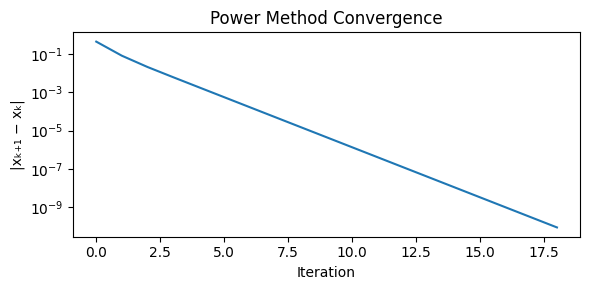

In [11]:
def power_method(A, max_iter=500, tol=1e-10):
    """Find the largest eigenvalue and eigenvector of A."""
    n = A.shape[0]
    x = np.random.randn(n)
    x /= np.linalg.norm(x)

    errors = []
    for k in range(max_iter):
        x_new = A @ x
        eigenvalue = x @ x_new           # Rayleigh quotient estimate
        x_new /= np.linalg.norm(x_new)
        errors.append(np.linalg.norm(x_new - x))
        if errors[-1] < tol:
            break
        x = x_new

    return eigenvalue, x, errors

# Test on a symmetric matrix with a clear dominant eigenvalue
A = np.diag([10., 3., 1.])   # eigenvalues 10, 3, 1 → ratio 3/10 = 0.3
R = np.linalg.qr(np.random.randn(3, 3))[0]   # random rotation
A = R @ A @ R.T   # random symmetric matrix with eigenvalues 10, 3, 1

lam_pow, v_pow, errs = power_method(A)
lam_true, vecs_true = np.linalg.eigh(A)

print(f"Power method λ₁ ≈ {lam_pow:.8f}")
print(f"True λ₁         = {lam_true[-1]:.8f}")
print(f"Converged in {len(errs)} iterations")

plt.figure(figsize=(6, 3))
plt.semilogy(errs)
plt.xlabel("Iteration"); plt.ylabel("|xₖ₊₁ − xₖ|")
plt.title("Power Method Convergence")
plt.tight_layout()
plt.show()

### 4.2 QR Method — full eigendecomposition

Repeat: $A_k = Q_k R_k$, then $A_{k+1} = R_k Q_k$.  
$A_k$ converges to an upper triangular matrix with eigenvalues on the diagonal.

In [12]:
def qr_iteration(A, max_iter=1000, tol=1e-8):
    """Basic QR iteration for symmetric matrices."""
    A_k = A.copy().astype(float)
    V   = np.eye(len(A))

    for k in range(max_iter):
        Q, R = np.linalg.qr(A_k)
        A_k  = R @ Q           # similarity transform: same eigenvalues
        V    = V @ Q           # accumulate eigenvectors

        off_diag = np.sum(np.abs(A_k - np.diag(np.diag(A_k))))
        if off_diag < tol:
            break

    return np.diag(A_k), V

n = 5
M = np.random.randn(n, n)
A_sym = (M + M.T) / 2

eigvals_qr, eigvecs_qr = qr_iteration(A_sym)
eigvals_true, eigvecs_true = np.linalg.eigh(A_sym)

print("QR eigenvalues  :", np.sort(eigvals_qr))
print("True eigenvalues:", eigvals_true)
print("Max eigenvalue error:", np.max(np.abs(np.sort(eigvals_qr) - eigvals_true)))

QR eigenvalues  : [-2.0490259   0.06104843  0.72362815  1.13311045  1.71486544]
True eigenvalues: [-2.0490259   0.06104843  0.72362815  1.13311045  1.71486544]
Max eigenvalue error: 1.7763568394002505e-15


### 4.3 Practical Eigenvalue APIs

In [13]:
from scipy.sparse.linalg import eigs, eigsh, svds

A = np.random.randn(100, 100)
A_sym = (A + A.T) / 2

# Full eigendecomposition (for dense matrices)
vals_full, vecs_full = np.linalg.eigh(A_sym)   # symmetric → eigh

# Top-k eigenvalues only (for large matrices where k << n)
k = 3
vals_k, vecs_k = eigsh(A_sym, k=k, which='LA')  # 'LA' = largest algebraic

print(f"Top {k} eigenvalues (full):", sorted(vals_full)[-k:][::-1])
print(f"Top {k} eigenvalues (eigsh):", sorted(vals_k)[-k:][::-1])

# SVD options
U_full, S_full, VT_full = np.linalg.svd(A, full_matrices=False)
U_k, S_k, VT_k = svds(A, k=k)   # top-k only
print(f"\nTop {k} singular values (full svd) :", S_full[:k])
print(f"Top {k} singular values (svds)     :", sorted(S_k)[::-1])

Top 3 eigenvalues (full): [np.float64(13.876117200377111), np.float64(13.72606806921968), np.float64(12.890756256128743)]
Top 3 eigenvalues (eigsh): [np.float64(13.876117200377063), np.float64(13.726068069219643), np.float64(12.89075625612875)]

Top 3 singular values (full svd) : [19.88520308 18.91789051 18.69274489]
Top 3 singular values (svds)     : [np.float64(19.88520307550995), np.float64(18.91789050670621), np.float64(18.6927448878165)]


---
## 5. Sparse Matrices

When most entries are zero, storing a full matrix wastes memory and computation. `scipy.sparse` stores only non-zero elements.

**Common formats**:
- **COO** (Coordinate): easy to construct
- **CSR** (Compressed Sparse Row): fast matrix-vector products ← most used
- **CSC** (Compressed Sparse Column): fast column slicing

In [14]:
# Create a sparse tridiagonal matrix (like a 1D Laplacian)
n = 2000
A_sparse = sparse.diags([-1, 2, -1], [-1, 0, 1], shape=(n, n), format='csr')

density = A_sparse.nnz / (n * n)
print(f"Matrix size    : {n} × {n} = {n*n:,} entries")
print(f"Non-zero (nnz) : {A_sparse.nnz:,}")
print(f"Density        : {density:.4%}")
print(f"Dense storage  : {n*n*8/1e6:.1f} MB")
print(f"Sparse storage : {(A_sparse.data.nbytes + A_sparse.indices.nbytes + A_sparse.indptr.nbytes)/1e6:.3f} MB")

Matrix size    : 2000 × 2000 = 4,000,000 entries
Non-zero (nnz) : 5,998
Density        : 0.1499%
Dense storage  : 32.0 MB
Sparse storage : 0.080 MB


In [15]:
b = np.ones(n)

# Direct sparse solver — good for n < 10,000
t0 = time.perf_counter()
x_direct = spla.spsolve(A_sparse, b)
t_direct = time.perf_counter() - t0

# Conjugate gradient — iterative, best for large SPD matrices
M_prec = sparse.diags(A_sparse.diagonal())   # diagonal preconditioner
t0 = time.perf_counter()
x_cg, info = spla.cg(A_sparse, b, M=M_prec, rtol=1e-10)
t_cg = time.perf_counter() - t0

print(f"Direct  solver: {t_direct:.4f}s  residual={np.linalg.norm(A_sparse @ x_direct - b):.2e}")
print(f"CG solver     : {t_cg:.4f}s  residual={np.linalg.norm(A_sparse @ x_cg - b):.2e}  info={info}")

Direct  solver: 0.0014s  residual=1.65e-09
CG solver     : 0.0283s  residual=0.00e+00  info=0


In [16]:
# Top-k eigenvalues of a large sparse matrix
from scipy.sparse.linalg import eigsh

k = 5
eigenvalues, eigenvectors = eigsh(A_sparse, k=k, which='SA')  # 'SA' = smallest algebraic
print(f"\nSmallest {k} eigenvalues of the tridiagonal matrix:")
print(sorted(eigenvalues))


Smallest 5 eigenvalues of the tridiagonal matrix:
[np.float64(2.464935042149757e-06), np.float64(9.859734092764658e-06), np.float64(2.218437892405794e-05), np.float64(3.943883915668669e-05), np.float64(6.162307225944089e-05)]


---
## 6. Randomised Algorithms

For very large matrices, exact algorithms may be too slow. **Randomised methods** trade a small approximation error for a large speed gain by using a random sketching matrix $S$ to reduce dimensionality.

**Key property**: choose $S$ so that $\mathbb{E}[SS^T] = I$, e.g., Gaussian $S \sim \mathcal{N}(0, 1/s)$.

### 6.1 Randomised Matrix Multiplication

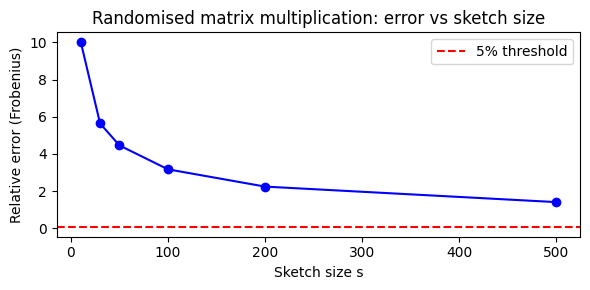

s=  10: error=10.037
s=  30: error=5.637
s=  50: error=4.456
s= 100: error=3.172
s= 200: error=2.245
s= 500: error=1.411


In [17]:
m, n, p = 500, 1000, 300
A = np.random.randn(m, n)
B = np.random.randn(n, p)

C_true = A @ B   # exact O(mnp)

errors, times_sketch, times_exact = [], [], []

sketch_sizes = [10, 30, 50, 100, 200, 500]
for s in sketch_sizes:
    S = np.random.randn(n, s) / np.sqrt(s)   # Gaussian sketch, scaled to preserve norms
    Y = A @ S    # m × s
    Z = S.T @ B  # s × p
    C_approx = Y @ Z
    err = np.linalg.norm(C_true - C_approx, 'fro') / np.linalg.norm(C_true, 'fro')
    errors.append(err)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(sketch_sizes, errors, 'bo-')
ax.set_xlabel('Sketch size s'); ax.set_ylabel('Relative error (Frobenius)')
ax.set_title('Randomised matrix multiplication: error vs sketch size')
ax.axhline(0.05, color='r', linestyle='--', label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

for s, e in zip(sketch_sizes, errors):
    print(f"s={s:4d}: error={e:.3f}")

### 6.2 Randomised SVD

**Algorithm** (for computing the top-k left singular vectors of $A$):
1. Form sketch $Y = AS$ where $S \sim \mathcal{N}(0, 1/s)$ is $n \times s$, $s = k + 10$
2. QR decompose $Y = QR$ to get orthonormal basis $Q$
3. Project: $B = Q^T A$ (small $s \times n$ matrix)
4. SVD of $B = \tilde{U}\Sigma\tilde{V}^T$ (cheap since $s \ll m$)
5. Recover: $U \approx Q\tilde{U}$

In [18]:
def randomized_svd(A, rank):
    """Randomised SVD: approximate top-`rank` singular triplets."""
    m, n = A.shape
    s = rank + 10          # oversampling improves accuracy
    S = np.random.randn(n, s)

    Y = A @ S              # m × s sketch
    Q, _ = np.linalg.qr(Y)  # orthonormal basis for column space of A

    B = Q.T @ A            # s × n  (cheap)
    U_tilde, Sigma, Vt = np.linalg.svd(B, full_matrices=False)

    U = Q @ U_tilde        # recover left singular vectors
    return U[:, :rank], Sigma[:rank], Vt[:rank, :]

# Build a low-rank matrix for testing
m, n, true_rank = 500, 400, 20
U_true = np.linalg.qr(np.random.randn(m, true_rank))[0]
V_true = np.linalg.qr(np.random.randn(n, true_rank))[0]
S_true = np.diag(np.arange(true_rank, 0, -1, dtype=float))
A_low_rank = U_true @ S_true @ V_true.T + 0.01 * np.random.randn(m, n)  # add small noise

# Compare randomised vs exact SVD
k = 10

t0 = time.perf_counter()
U_r, S_r, VT_r = randomized_svd(A_low_rank, k)
t_rand = time.perf_counter() - t0

t0 = time.perf_counter()
U_e, S_e, VT_e = np.linalg.svd(A_low_rank, full_matrices=False)
t_exact = time.perf_counter() - t0

print(f"Exact  SVD: {t_exact:.4f}s")
print(f"Random SVD: {t_rand:.4f}s  ({t_exact/max(t_rand,1e-9):.1f}× faster)")
print(f"Singular values error (top {k}): {np.max(np.abs(S_r - S_e[:k])):.4f}")

Exact  SVD: 0.0232s
Random SVD: 0.0023s  (10.2× faster)
Singular values error (top 10): 0.3080


### 6.3 Image Compression with SVD

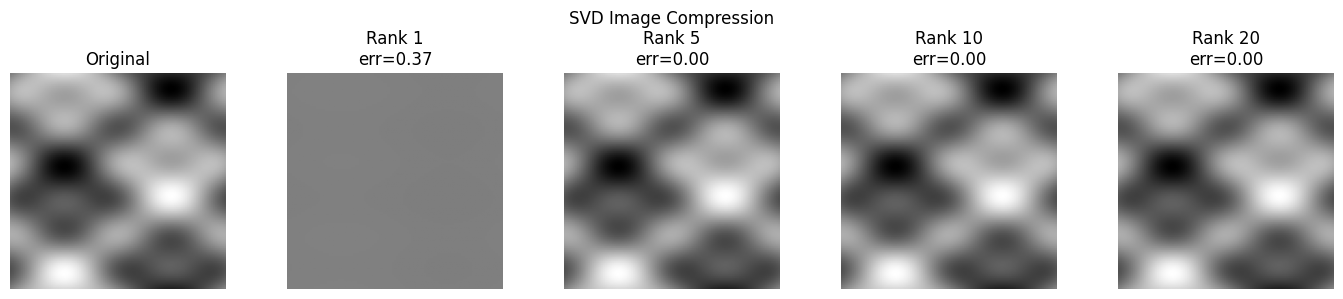

In [19]:
# Create a synthetic "image" (gradient + pattern) for demonstration
np.random.seed(0)
height, width = 100, 100
x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X_grid, Y_grid = np.meshgrid(x, y)
img = (np.sin(X_grid) * np.cos(Y_grid) +
       0.5 * np.cos(2 * X_grid) * np.sin(3 * Y_grid))
img = (img - img.min()) / (img.max() - img.min())  # normalise to [0,1]

# Compress using truncated SVD
ranks = [1, 5, 10, 20]
U_full, S_full, VT_full = np.linalg.svd(img, full_matrices=False)

fig, axes = plt.subplots(1, len(ranks) + 1, figsize=(14, 3))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original")

for ax, r in zip(axes[1:], ranks):
    img_r = U_full[:, :r] @ np.diag(S_full[:r]) @ VT_full[:r, :]
    err = np.linalg.norm(img - img_r, 'fro') / np.linalg.norm(img, 'fro')
    ax.imshow(np.clip(img_r, 0, 1), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"Rank {r}\nerr={err:.2f}")

for ax in axes: ax.axis('off')
plt.suptitle('SVD Image Compression')
plt.tight_layout()
plt.show()

---
## 7. GPU Acceleration (Overview)

Modern GPUs have thousands of cores optimised for parallel floating-point operations — ideal for matrix computations.  
**CuPy** is a drop-in NumPy replacement with GPU support: just `import cupy as np`.

Typical speedup: **10–100×** for large dense linear algebra.

> This section requires an NVIDIA GPU with CUDA. The code below shows the pattern but cannot run on a CPU-only machine.

In [20]:
# GPU Linear Algebra with CuPy
# Install: pip install cupy-cuda12x  (match your CUDA version)

GPU_AVAILABLE = False
try:
    import cupy as cp
    GPU_AVAILABLE = True
except ImportError:
    print("CuPy not installed. Showing CPU NumPy code instead.")

if GPU_AVAILABLE:
    n = 5000
    # Everything looks identical to NumPy — just use cp instead of np
    A_gpu = cp.random.rand(n, n)
    B_gpu = cp.random.rand(n, n)

    # Warm up
    _ = A_gpu @ B_gpu
    cp.cuda.stream.get_current_stream().synchronize()

    # Benchmark GPU matmul
    t0 = time.perf_counter()
    C_gpu = A_gpu @ B_gpu
    cp.cuda.stream.get_current_stream().synchronize()
    t_gpu = time.perf_counter() - t0

    # Benchmark CPU matmul
    A_cpu = cp.asnumpy(A_gpu)
    B_cpu = cp.asnumpy(B_gpu)
    t0 = time.perf_counter()
    C_cpu = A_cpu @ B_cpu
    t_cpu = time.perf_counter() - t0

    print(f"{n}×{n} matrix multiply:")
    print(f"  CPU (NumPy): {t_cpu:.3f}s")
    print(f"  GPU (CuPy) : {t_gpu:.3f}s  ({t_cpu/max(t_gpu,1e-9):.1f}× speedup)")
else:
    print("""
GPU code pattern (identical to NumPy, just change the import):

    import cupy as np          # ← only this line changes!
    A = np.random.rand(5000, 5000)
    B = np.random.rand(5000, 5000)
    C = A @ B                  # runs on GPU
    x = np.linalg.solve(A, b)  # also GPU-accelerated
""")

CuPy not installed. Showing CPU NumPy code instead.

GPU code pattern (identical to NumPy, just change the import):

    import cupy as np          # ← only this line changes!
    A = np.random.rand(5000, 5000)
    B = np.random.rand(5000, 5000)
    C = A @ B                  # runs on GPU
    x = np.linalg.solve(A, b)  # also GPU-accelerated



---
## 8. Summary and Best-Practice Checklist

| Task | Recommended Tool | Notes |
|---|---|---|
| Dense linear system $Ax=b$ | `scipy.linalg.solve` | Use `assume_a='pos'` for SPD |
| Multiple right-hand sides | Save LU once, re-use | O(n²) per solve after O(n³) factorisation |
| Eigenvalues, symmetric | `np.linalg.eigh` | Real eigenvalues, sorted |
| Top-k eigenvalues (large) | `scipy.sparse.linalg.eigsh` | Much faster when k ≪ n |
| SVD | `np.linalg.svd` / `svds` | Use `full_matrices=False` |
| Large sparse systems | `scipy.sparse.linalg.cg` / `gmres` | Add preconditioner |
| Approximate SVD | `randomized_svd` (above) | Excellent for low-rank matrices |
| GPU acceleration | `cupy` (drop-in for NumPy) | 10–100× for large matrices |

**Golden rules**:
1. Never use `inv(A)` — always `solve(A, b)`
2. Tell SciPy about matrix structure (`assume_a='pos'`, `eigh` vs `eig`)
3. For sparse matrices, stay sparse — avoid `toarray()` on large matrices
4. Condition number ≫ 1 → results may be unreliable regardless of algorithm